# Diagonalizing $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- hamiltonian

$$
\begin{align}
    H&=\sum_{\mathbf{k}}[t_{\uparrow\uparrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\uparrow\downarrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})+t_{\downarrow\uparrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\downarrow\downarrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})]-i\frac{\gamma}{2}\sum_{\mathbf{r}}n_\uparrow(\mathbf{r}) n_\downarrow(\mathbf{r}) \\
    &=\underbrace{\sum_{\mathbf{k}}\left[\varepsilon_1(\mathbf{k})c_1^\dagger(\mathbf{k})c_1(\mathbf{k}) + \varepsilon_2(\mathbf{k})c_2^\dagger(\mathbf{k})c_2(\mathbf{k})\right]}_{H_0} + \underbrace{\frac{-1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')}_{V_\text{loss}}
\end{align}

$$

$$t_{\uparrow\uparrow}=\frac{\hbar^2(k-q)^2}{2m_\mathrm{Yb}}+\frac{\delta}{2},\quad t_{\uparrow\downarrow}= t_{\downarrow\uparrow}=\frac{\Omega_R}{2},\quad t_{\downarrow\downarrow}=\frac{\hbar^2(k+q)^2}{2m_\mathrm{Yb}}-\frac{\delta}{2}$$

$$
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & \beta(\mathbf{k}) \\
    -\beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix},\quad
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & -\beta(\mathbf{k}) \\
    \beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
$$


$$\alpha(\mathbf{k}) = \cos\theta(\mathbf{k}),\quad\beta(\mathbf{k}) = \sin\theta(\mathbf{k}),\quad\theta(\mathbf k)=\frac{1}{2}\arctan\frac{\Omega_R}{\frac{\hbar^2}{2m_\mathrm{Yb}}((\mathbf{k}-\mathbf{q})^2-(\mathbf{k}+\mathbf{q})^2) + \delta}$$


- fourier transforms

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

- basis

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$

Use the matrix repersentation 
$$[H]_{\mathcal{B}}$$
to calculate physical properties

In [2]:
import os
import time
import gc
import itertools
import functools
import operator
import pickle
from pprint import pprint

os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update("jax_enable_x64", True)
from jax.extend.backend import get_backend
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

from ybsoc import *

## diagonalize & save

### 2-body Dissipation $\gamma$ vs $\chi$

In [3]:
simulation_name = "dissipative"
data_dir = "/home/pco0511/yb-soc-two-body-loss/data"
root_path = os.path.join(data_dir, simulation_name)

metadata_path = os.path.join(root_path, "metadata.pkl")
eigenvector_path = os.path.join(root_path, "eigenvectors")
eigenvalue_path = os.path.join(root_path, "eigenvalues")
mics_path = os.path.join(root_path, "miscellaneous")

metadata = {
    "fixed": {
        "d":1,
        "lengths":[10,],
        "n_particle":4,
        "hbar":1,
        "q":0.03,
        "m_Yb":1,
        "delta":0.08,
        "omega_R":0.2,
        # "gamma":0.1,
    },
    "unfixed": {
        "gamma": list(np.linspace(-1, 1, 101)),
    },
}

os.makedirs(eigenvector_path, exist_ok=True)
os.makedirs(eigenvalue_path, exist_ok=True)
os.makedirs(mics_path, exist_ok=True)

data_len = functools.reduce(operator.mul, [len(p) for p in metadata["unfixed"].values()], 1)

min_E_i_sus = np.empty((data_len,))
max_E_i_sus = np.empty((data_len,))
min_E_r_sus = np.empty((data_len,))

for idx, unfixed_params in tqdm.tqdm(enumerate(itertools.product(*metadata["unfixed"].values())), total=data_len):
    keys = metadata["unfixed"].keys()
    unfixed_params = dict(zip(keys, unfixed_params))
    system = YbSOC2bodyLoss(
        **metadata["fixed"],
        **unfixed_params,
        array_type='jax'
    )
    hamiltonian = system.dense_hamiltonian()
    eigenvalues, eigenvectors = jnp.linalg.eig(hamiltonian)
    # save_data
    np.save(os.path.join(eigenvalue_path, f"{idx}.npy"), np.array(eigenvalues))
    np.save(os.path.join(eigenvector_path, f"{idx}.npy"), np.array(eigenvectors))

    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    max_E_i_idx = jnp.argmax(E_i)

    indices = jnp.array([min_E_r_idx, min_E_i_idx, max_E_i_idx])
    
    reduced_eigenvectors = eigenvectors[:, indices]
    
    suseptibility_matrix = system.pair_susceptibility_matrix()
    suseptibility = jnp.einsum('ji,jk,ki->i', reduced_eigenvectors.conj(), suseptibility_matrix, reduced_eigenvectors)
    
    min_E_r_sus[idx] = suseptibility[0].astype(jnp.float64)
    min_E_i_sus[idx] = suseptibility[1].astype(jnp.float64)
    max_E_i_sus[idx] = suseptibility[2].astype(jnp.float64)
    
    del system, hamiltonian, eigenvalues, eigenvectors, reduced_eigenvectors, suseptibility_matrix, suseptibility, E_r, E_i
    gc.collect()


with open(metadata_path, "wb") as f:
    pickle.dump(metadata, f)

np.save(os.path.join(mics_path, "min_E_i_sus.npy"), min_E_i_sus)
np.save(os.path.join(mics_path, "max_E_i_sus.npy"), max_E_i_sus)
np.save(os.path.join(mics_path, "min_E_r_sus.npy"), min_E_r_sus)


100%|██████████| 101/101 [1:33:50<00:00, 55.74s/it]


### on-site interaction $U$ vs $\chi$

In [4]:
simulation_name = "hubbard"
data_dir = "/home/pco0511/yb-soc-two-body-loss/data"
root_path = os.path.join(data_dir, simulation_name)

metadata_path = os.path.join(root_path, "metadata.pkl")
eigenvector_path = os.path.join(root_path, "eigenvectors")
eigenvalue_path = os.path.join(root_path, "eigenvalues")
mics_path = os.path.join(root_path, "miscellaneous")

metadata = {
    "fixed": {
        "d":1,
        "lengths":[10,],
        "n_particle":4,
        "hbar":1,
        "q":0.03,
        "m_Yb":1,
        "delta":0.08,
        "omega_R":0.2,
        # "gamma":0.1,
    },
    "unfixed": {
        "U": list(np.linspace(-1, 1, 101)),
    },
}

os.makedirs(eigenvector_path, exist_ok=True)
os.makedirs(eigenvalue_path, exist_ok=True)
os.makedirs(mics_path, exist_ok=True)

data_len = functools.reduce(operator.mul, [len(p) for p in metadata["unfixed"].values()], 1)

min_E_i_sus = np.empty((data_len,))
max_E_i_sus = np.empty((data_len,))
min_E_r_sus = np.empty((data_len,))

for idx, unfixed_params in tqdm.tqdm(enumerate(itertools.product(*metadata["unfixed"].values())), total=data_len):
    keys = metadata["unfixed"].keys()
    unfixed_params = dict(zip(keys, unfixed_params))
    system = YbSOCSystem(
        **metadata["fixed"],
        **unfixed_params,
        array_type='jax'
    )
    hamiltonian = system.dense_hamiltonian()
    eigenvalues, eigenvectors = jnp.linalg.eigh(hamiltonian)
    # save_data
    np.save(os.path.join(eigenvalue_path, f"{idx}.npy"), np.array(eigenvalues))
    np.save(os.path.join(eigenvector_path, f"{idx}.npy"), np.array(eigenvectors))

    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    max_E_i_idx = jnp.argmax(E_i)

    indices = jnp.array([min_E_r_idx, min_E_i_idx, max_E_i_idx])
    
    reduced_eigenvectors = eigenvectors[:, indices]
    
    suseptibility_matrix = system.pair_susceptibility_matrix()
    suseptibility = jnp.einsum('ji,jk,ki->i', reduced_eigenvectors.conj(), suseptibility_matrix, reduced_eigenvectors)
    
    min_E_r_sus[idx] = suseptibility[0].astype(jnp.float64)
    min_E_i_sus[idx] = suseptibility[1].astype(jnp.float64)
    max_E_i_sus[idx] = suseptibility[2].astype(jnp.float64)
    
    del system, hamiltonian, eigenvalues, eigenvectors, reduced_eigenvectors, suseptibility_matrix, suseptibility, E_r, E_i
    gc.collect()

with open(metadata_path, "wb") as f:
    pickle.dump(metadata, f)

np.save(os.path.join(mics_path, "min_E_i_sus.npy"), min_E_i_sus)
np.save(os.path.join(mics_path, "max_E_i_sus.npy"), max_E_i_sus)
np.save(os.path.join(mics_path, "min_E_r_sus.npy"), min_E_r_sus)


100%|██████████| 101/101 [09:26<00:00,  5.61s/it]


### size vs $\chi$

In [ ]:
simulation_name = "scale"
data_dir = "/home/pco0511/yb-soc-two-body-loss/data"
root_path = os.path.join(data_dir, simulation_name)

metadata_path = os.path.join(root_path, "metadata.pkl")
eigenvector_path = os.path.join(root_path, "eigenvectors")
eigenvalue_path = os.path.join(root_path, "eigenvalues")
mics_path = os.path.join(root_path, "miscellaneous")

metadata = {
    "fixed": {
        "d":1,
        # "lengths":[10,],
        # "n_particle":4,
        "hbar":1,
        "q":0.03,
        "m_Yb":1,
        "delta":0.08,
        "omega_R":0.2,
        # "gamma":0.1,
    },
    "unfixed": {
        "lengths": [[nx,] for nx in range(4, 9)],
        "n_particle": list(np.linspace(1, 8, 8, dtype=np.int32)),
        "gamma": list(np.linspace(-0.5, 0.5, 11)),
    },
}


os.makedirs(eigenvector_path, exist_ok=True)
os.makedirs(eigenvalue_path, exist_ok=True)
os.makedirs(mics_path, exist_ok=True)

with open(metadata_path, "wb") as f:
    pickle.dump(metadata, f)
    
data_len = functools.reduce(operator.mul, [len(p) for p in metadata["unfixed"].values()], 1)

min_E_i_sus = np.empty((data_len,))
max_E_i_sus = np.empty((data_len,))
min_E_r_sus = np.empty((data_len,))

for idx, unfixed_params in tqdm.tqdm(enumerate(itertools.product(*metadata["unfixed"].values())), total=data_len):
    # if idx < 415:
    #     continue
    keys = metadata["unfixed"].keys()
    unfixed_params = dict(zip(keys, unfixed_params))
    system = YbSOC2bodyLoss(
        **metadata["fixed"],
        **unfixed_params,
        array_type='jax'
    )
    hamiltonian = system.dense_hamiltonian()
    eigenvalues, eigenvectors = jnp.linalg.eig(hamiltonian)
    # save_data
    np.save(os.path.join(eigenvalue_path, f"{idx}.npy"), np.array(eigenvalues))
    np.save(os.path.join(eigenvector_path, f"{idx}.npy"), np.array(eigenvectors))
    
    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    max_E_i_idx = jnp.argmax(E_i)

    indices = jnp.array([min_E_r_idx, min_E_i_idx, max_E_i_idx])

    reduced_eigenvectors = eigenvectors[:, indices]

    suseptibility_matrix = system.pair_susceptibility_matrix()
    suseptibility = jnp.einsum('ji,jk,ki->i', reduced_eigenvectors.conj(), suseptibility_matrix, reduced_eigenvectors)

    min_E_r_sus[idx] = suseptibility[0].astype(jnp.float64)
    min_E_i_sus[idx] = suseptibility[1].astype(jnp.float64)
    max_E_i_sus[idx] = suseptibility[2].astype(jnp.float64)

    del system, hamiltonian, eigenvalues, eigenvectors, reduced_eigenvectors, suseptibility_matrix, suseptibility, E_r, E_i
    gc.collect()
    
np.save(os.path.join(mics_path, "min_E_i_sus.npy"), min_E_i_sus)
np.save(os.path.join(mics_path, "max_E_i_sus.npy"), max_E_i_sus)
np.save(os.path.join(mics_path, "min_E_r_sus.npy"), min_E_r_sus)


Made changes.

## Load & Plot

In [5]:
simulation_name = "hubbard"

data_dir = "/home/pco0511/yb-soc-two-body-loss/data"
root_path = os.path.join(data_dir, simulation_name)

metadata_path = os.path.join(root_path, "metadata.pkl")
eigenvector_path = os.path.join(root_path, "eigenvectors")
eigenvalue_path = os.path.join(root_path, "eigenvalues")
mics_path = os.path.join(root_path, "miscellaneous")

with open(metadata_path, 'rb') as f:
    metadata = pickle.load(f)

data_len = functools.reduce(operator.mul, [len(p) for p in metadata["unfixed"].values()], 1)

pprint(metadata)

{'fixed': {'d': 1,
           'delta': 0.08,
           'hbar': 1,
           'lengths': [10],
           'm_Yb': 1,
           'n_particle': 4,
           'omega_R': 0.2,
           'q': 0.03},
 'unfixed': {'U': [np.float64(-1.0),
                   np.float64(-0.98),
                   np.float64(-0.96),
                   np.float64(-0.94),
                   np.float64(-0.92),
                   np.float64(-0.9),
                   np.float64(-0.88),
                   np.float64(-0.86),
                   np.float64(-0.84),
                   np.float64(-0.8200000000000001),
                   np.float64(-0.8),
                   np.float64(-0.78),
                   np.float64(-0.76),
                   np.float64(-0.74),
                   np.float64(-0.72),
                   np.float64(-0.7),
                   np.float64(-0.6799999999999999),
                   np.float64(-0.6599999999999999),
                   np.float64(-0.64),
                   np.float64(-0.62),
       

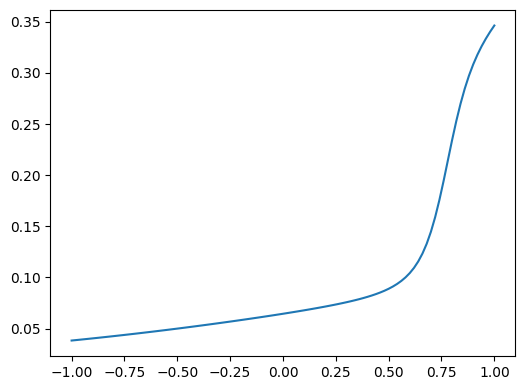

In [ ]:
U = metadata["unfixed"]["U"]

min_E_i_sus = np.load(os.path.join(mics_path, "min_E_i_sus.npy"))
max_E_i_sus = np.load(os.path.join(mics_path, "max_E_i_sus.npy"))
min_E_r_sus = np.load(os.path.join(mics_path, "min_E_r_sus.npy"))

plt.figure(figsize=(6, 4.5))

# plt.plot(U, min_E_i_sus, label="$\\chi$ (min $E_i$)")
# plt.plot(U, max_E_i_sus, label="$\\chi$ (max $E_i$)")
plt.plot(U, min_E_r_sus, label="$\\chi$ (min $E_r$)")

plt.show()

In [13]:
simulation_name = "dissipative"

data_dir = "/home/pco0511/yb-soc-two-body-loss/data"
root_path = os.path.join(data_dir, simulation_name)

metadata_path = os.path.join(root_path, "metadata.pkl")
eigenvector_path = os.path.join(root_path, "eigenvectors")
eigenvalue_path = os.path.join(root_path, "eigenvalues")
mics_path = os.path.join(root_path, "miscellaneous")

with open(metadata_path, 'rb') as f:
    metadata = pickle.load(f)

data_len = functools.reduce(operator.mul, [len(p) for p in metadata["unfixed"].values()], 1)

pprint(metadata)

{'fixed': {'d': 1,
           'delta': 0.08,
           'hbar': 1,
           'lengths': [10],
           'm_Yb': 1,
           'n_particle': 4,
           'omega_R': 0.2,
           'q': 0.03},
 'unfixed': {'gamma': [np.float64(-1.0),
                       np.float64(-0.98),
                       np.float64(-0.96),
                       np.float64(-0.94),
                       np.float64(-0.92),
                       np.float64(-0.9),
                       np.float64(-0.88),
                       np.float64(-0.86),
                       np.float64(-0.84),
                       np.float64(-0.8200000000000001),
                       np.float64(-0.8),
                       np.float64(-0.78),
                       np.float64(-0.76),
                       np.float64(-0.74),
                       np.float64(-0.72),
                       np.float64(-0.7),
                       np.float64(-0.6799999999999999),
                       np.float64(-0.6599999999999999),
           

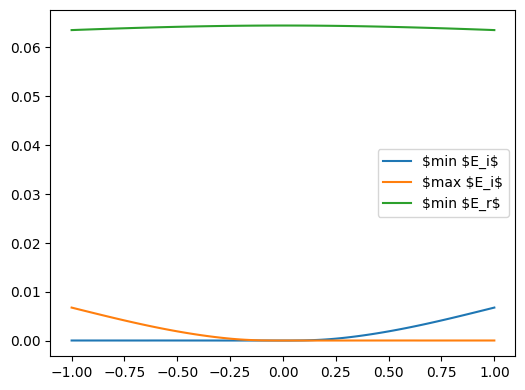

In [14]:
gamma = metadata["unfixed"]["gamma"]

min_E_i_sus = np.load(os.path.join(mics_path, "min_E_i_sus.npy"))
max_E_i_sus = np.load(os.path.join(mics_path, "max_E_i_sus.npy"))
min_E_r_sus = np.load(os.path.join(mics_path, "min_E_r_sus.npy"))

plt.figure(figsize=(6, 4.5))

center_index = len(gamma) // 2
min_E_i_sus[center_index] = 0
max_E_i_sus[center_index] = 0

plt.plot(gamma, min_E_i_sus, label=f"$min $E_i$")
plt.plot(gamma, max_E_i_sus, label=f"$max $E_i$")
plt.plot(gamma, min_E_r_sus, label=f"$min $E_r$")

plt.legend()

plt.show()

In [ ]:
def draw_Er_vs_Ei(eigenvalues, eigenvectors, colors, title, cbar_label, save_path = None):
    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    plt.figure(figsize=(6, 4.5))
    scatter = plt.scatter(E_r, E_i, c=colors, alpha=0.7, s=5)

    cbar = plt.colorbar(scatter)
    cbar.set_label(cbar_label)

    plt.xlabel("E_r (Real part)")
    plt.ylabel("E_i (Imag part)")
    plt.title(title)

    # plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.close()

In [ ]:
system = YbSOC2bodyLoss(
    d=1,
    lengths=[8],
    n_particle=6,
    hbar=1,
    q= 0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.06,
    gamma = 0.03,
    array_type='numpy'
)
hamiltonian = system.dense_hamiltonian(
    display_progress=True
)
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

100%|██████████| 8008/8008 [00:01<00:00, 5646.96it/s]


In [ ]:
E_r = jnp.real(eigenvalues)
E_i = jnp.imag(eigenvalues)

min_E_r_idx = jnp.argmin(E_r)
min_E_i_idx = jnp.argmin(E_i)
max_E_i_idx = jnp.argmax(E_i)

suseptibility_matrix = system.pair_susceptibility_matrix()
suseptibility = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), suseptibility_matrix, eigenvectors)

min_E_r_sus = suseptibility[min_E_r_idx].astype(jnp.float64)
min_E_i_sus = suseptibility[min_E_i_idx].astype(jnp.float64)
max_E_i_sus = suseptibility[max_E_i_idx].astype(jnp.float64)

draw_Er_vs_Ei(eigenvalues, eigenvectors, colors=suseptibility, title="E_r vs E_i", cbar_label='$\\frac{(2\\pi)^d}{N^2}\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')